# 16. Governance, Fairness, Privacy, and Human Review

An anomaly detector becomes a decision system when it sends cases to investigators, blocks accounts, triggers customer friction, or surfaces private telemetry. 

This notebook studies the governance layer around anomaly detection: subgroup false alarms, privacy-sensitive features, review capacity, escalation rules, audit records, and human override. The goal is not to make governance decorative. The goal is to make it measurable.

## Learning Objectives

By the end of this notebook, you should be able to:

- Translate anomaly scores into governed actions: no action, human review, temporary hold, or escalation.
- Measure subgroup alert burden, false positive rates, precision, and review allocation.
- Explain why privacy is not solved by simply removing obvious identifiers.
- Use differential privacy as a mathematical reference point for noisy aggregate monitoring.
- Design human review queues that respect capacity, uncertainty, and auditability.
- Write a decision memo that states risk, guardrails, and monitoring responsibilities.

## 1. Why Governance Belongs Inside the Detection Workflow

A detector that only produces scores can look technically successful while creating operational harm. In high-stakes environments, alerting decisions can:

| Governance risk | Example in anomaly detection | Required control |
|---|---|---|
| False positive burden | Legitimate customers are repeatedly reviewed or blocked | Subgroup false positive monitoring |
| Automation harm | A high score automatically freezes an account | Human review and escalation rules |
| Privacy leakage | Investigation dashboards expose raw location, device, or identity fields | Data minimization and privacy-preserving aggregates |
| Capacity failure | Analysts receive more alerts than they can review | Review queue design and triage thresholds |
| Accountability gap | Nobody can explain why an action was taken | Audit records and model cards |
| Distribution shift | A new product/channel changes normal behavior | Drift monitoring and threshold review |

Fairness work in machine learning emphasizes that decision systems should be evaluated by how errors and decisions are distributed across groups, by subgroup error patterns alongside global accuracy (Dwork et al., 2012; Hardt et al., 2016). Human-AI work similarly treats deferral and review as part of the predictive system rather than an afterthought (Madras et al., 2017; Bondi et al., 2022).

## 2. Mathematical Setup

For account or event $i$, let

$$
x_i \in \mathbb{R}^p
$$

be observed features, let $g_i \in \mathcal{G}$ be a governance attribute such as region, channel, language, or another protected or operationally sensitive subgroup, and let

$$
y_i \in \{0,1\}
$$

represent the later-confirmed incident label. In many anomaly settings $y_i$ is delayed, incomplete, or available only for reviewed cases.

A detector produces an anomaly score

$$
s_i = f(x_i), \qquad 0 \leq s_i \leq 1,
$$

and a policy maps scores and context to an action

$$
a_i = \pi(s_i, x_i, g_i) \in \{\text{no action}, \text{review}, \text{temporary hold}, \text{escalate}\}.
$$

A simple threshold policy is

$$
\pi(s_i) =
\begin{cases}
\text{temporary hold}, & s_i \geq \tau_{\mathrm{auto}}, \\
\text{human review}, & \tau_{\mathrm{review}} \leq s_i < \tau_{\mathrm{auto}}, \\
\text{no action}, & s_i < \tau_{\mathrm{review}}.
\end{cases}
$$

But governance usually requires more than two thresholds. Let

$$
R_i = \mathbb{1}\{a_i = \text{review}\}, \qquad H_i = \mathbb{1}\{a_i = \text{temporary hold}\}.
$$

With review capacity $B$, the queue must satisfy

$$
\sum_i R_i \leq B.
$$

Useful subgroup diagnostics include:

$$
\mathrm{AlertRate}(g) = \Pr(R_i = 1 \text{ or } H_i = 1 \mid g_i = g),
$$

$$
\mathrm{FPR}(g) = \Pr(R_i = 1 \text{ or } H_i = 1 \mid y_i = 0, g_i = g),
$$

$$
\mathrm{TPR}(g) = \Pr(R_i = 1 \text{ or } H_i = 1 \mid y_i = 1, g_i = g),
$$

and

$$
\mathrm{PPV}(g) = \Pr(y_i = 1 \mid R_i = 1 \text{ or } H_i = 1, g_i = g).
$$

These are not the only possible fairness metrics. They are practical metrics for anomaly detection because most operational harm is created by false alarms, queue allocation, and automated interventions.

## 3. Imports and Display Settings

In [1]:
# Section focus: 3. Imports and Display Settings.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 160)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

print(f'Python: {sys.version.split()[0]}')
print(f'pandas: {pd.__version__}')

Python: 3.12.3
pandas: 3.0.3


## 4. Synthetic Case: Account-Risk Alerts

Suppose a marketplace monitors account sessions for suspicious behavior. The detector can send cases to human review, temporarily hold high-risk accounts, or do nothing.

The governance attribute is `access_channel`:

| Channel | Interpretation in this simulation | Governance concern |
|---|---|---|
| `Established web` | Stable web users with reliable device/location telemetry | Usually lower measurement noise |
| `Mobile heavy` | Frequent device changes and app-based access | Device churn may look suspicious |
| `Low observability` | Regions or contexts with less reliable network/location signals | Location and proxy indicators may over-alert legitimate users |

The true incident rate is not set by the channel directly. However, the detector sees noisy proxies that vary across channels, which can create unequal false positive burden.

In [2]:
def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


def robust_z(series):
    """Carry out the robust z step used in the 16. Governance, Fairness, Privacy, and Human Review workflow.
    
    Parameters
    ----------
    series : object
        One-dimensional pandas object whose distribution or most common value is being inspected.
    
    Returns
    -------
    object
        Intermediate result produced by the robust z calculation and reused by later cells.
    """
    median = np.median(series)
    mad = np.median(np.abs(series - median))
    return (series - median) / (1.4826 * mad + 1e-6)


def simulate_account_risk(n=12000, seed=RANDOM_SEED):
    """Create a simulated account risk data set for the 16. Governance, Fairness, Privacy, and Human Review case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    channels = np.array(['Established web', 'Mobile heavy', 'Low observability'])
    channel = rng.choice(channels, size=n, p=[0.54, 0.31, 0.15])
    channel_idx = {name: i for i, name in enumerate(channels)}
    c = np.array([channel_idx[x] for x in channel])

    account_age_days = np.where(
        channel == 'Established web',
        rng.gamma(7.5, 75, size=n),
        np.where(channel == 'Mobile heavy', rng.gamma(4.8, 55, size=n), rng.gamma(3.5, 45, size=n)),
    )

    login_velocity = rng.gamma(2.1 + 0.15 * (c == 1), 1.2, size=n)
    failed_login_count = rng.poisson(0.45 + 0.25 * (c == 1) + 0.15 * (c == 2), size=n)
    device_churn = rng.gamma(1.4 + 0.55 * (c == 1) + 0.75 * (c == 2), 0.9, size=n)
    geo_distance_km = rng.gamma(1.8 + 1.2 * (c == 2), 160 + 70 * (c == 2), size=n)
    proxy_network = rng.binomial(1, 0.035 + 0.035 * (c == 1) + 0.14 * (c == 2), size=n)
    night_activity = rng.binomial(1, 0.10 + 0.04 * (c == 1) + 0.03 * (c == 2), size=n)
    prior_chargeback = rng.binomial(1, 0.025 + 0.012 * (c == 1), size=n)
    spend_deviation = rng.gamma(2.0 + 0.1 * (c == 2), 1.0, size=n)

    latent_risk = (
        -5.0
        + 0.38 * login_velocity
        + 0.50 * failed_login_count
        + 0.45 * prior_chargeback
        + 0.50 * proxy_network
        + 0.32 * night_activity
        + 0.22 * spend_deviation
        + 0.0015 * geo_distance_km
        + 0.18 * device_churn
    )
    true_incident = rng.binomial(1, sigmoid(latent_risk))

    # True incidents create sharper patterns. Legitimate low-observability users still
    # have high location/proxy noise, which creates governance risk for naive scores.
    login_velocity = login_velocity + true_incident * rng.gamma(2.0, 1.1, size=n)
    failed_login_count = failed_login_count + true_incident * rng.poisson(2.0, size=n)
    device_churn = device_churn + true_incident * rng.gamma(1.6, 0.9, size=n)
    geo_distance_km = geo_distance_km + true_incident * rng.gamma(2.2, 180, size=n)
    spend_deviation = spend_deviation + true_incident * rng.gamma(1.5, 1.0, size=n)

    df = pd.DataFrame({
        'case_id': [f'case_{i:05d}' for i in range(n)],
        'access_channel': channel,
        'account_age_days': account_age_days,
        'login_velocity': login_velocity,
        'failed_login_count': failed_login_count,
        'device_churn': device_churn,
        'geo_distance_km': geo_distance_km,
        'proxy_network': proxy_network,
        'night_activity': night_activity,
        'prior_chargeback': prior_chargeback,
        'spend_deviation': spend_deviation,
        'true_incident': true_incident,
    })
    return df

accounts = simulate_account_risk()

for col in ['account_age_days', 'login_velocity', 'failed_login_count', 'device_churn', 'geo_distance_km', 'spend_deviation']:
    accounts[f'{col}_z'] = robust_z(accounts[col]).clip(-5, 8)

summary = (
    accounts.groupby('access_channel')
    .agg(
        cases=('case_id', 'count'),
        incident_rate=('true_incident', 'mean'),
        median_geo_distance=('geo_distance_km', 'median'),
        proxy_share=('proxy_network', 'mean'),
        median_device_churn=('device_churn', 'median'),
    )
    .assign(population_share=lambda d: d['cases'] / len(accounts))
    .reset_index()
)
summary.round(3)

,access_channel,cases,incident_rate,median_geo_distance,proxy_share,median_device_churn,population_share
0,Established web,6405,0.090,259.062,0.041,1.083,0.534
1,Low observability,1856,0.184,674.548,0.184,1.846,0.155
2,Mobile heavy,3739,0.111,250.896,0.067,1.545,0.312


The incident rate differs across channels because the observed risk factors differ, but the governance problem is subtler: some high-scoring features are also noisier in the low-observability channel. A detector can become operationally unfair even when channel is not explicitly used as a scoring input.

## 5. Baseline Score and Baseline Policy

First build a transparent score that puts substantial weight on location and device signals. This is a plausible early anomaly detector, but it is not yet governed.

In [3]:
# Section focus: 5. Baseline Score and Baseline Policy.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

accounts['baseline_score'] = sigmoid(
    -2.45
    + 0.45 * accounts['login_velocity_z']
    + 0.34 * accounts['failed_login_count_z']
    + 0.50 * accounts['device_churn_z']
    + 0.62 * accounts['geo_distance_km_z']
    + 0.62 * accounts['proxy_network']
    + 0.40 * accounts['night_activity']
    + 0.62 * accounts['prior_chargeback']
    + 0.32 * accounts['spend_deviation_z']
)

accounts['evidence_count'] = (
    (accounts['login_velocity_z'] > 2.0).astype(int)
    + (accounts['failed_login_count_z'] > 2.0).astype(int)
    + (accounts['device_churn_z'] > 2.2).astype(int)
    + (accounts['geo_distance_km_z'] > 2.4).astype(int)
    + accounts['proxy_network'].astype(int)
    + accounts['prior_chargeback'].astype(int)
    + (accounts['spend_deviation_z'] > 2.3).astype(int)
)

review_threshold = accounts['baseline_score'].quantile(0.900)
auto_threshold = accounts['baseline_score'].quantile(0.985)

accounts['baseline_action'] = np.select(
    [accounts['baseline_score'] >= auto_threshold, accounts['baseline_score'] >= review_threshold],
    ['temporary_hold', 'human_review'],
    default='no_action',
)

baseline_policy_summary = pd.DataFrame([
    {'quantity': 'Review threshold', 'value': review_threshold},
    {'quantity': 'Temporary-hold threshold', 'value': auto_threshold},
    {'quantity': 'Review or hold cases', 'value': (accounts['baseline_action'] != 'no_action').sum()},
    {'quantity': 'Temporary holds', 'value': (accounts['baseline_action'] == 'temporary_hold').sum()},
    {'quantity': 'Overall precision among acted cases', 'value': accounts.loc[accounts['baseline_action'] != 'no_action', 'true_incident'].mean()},
])
baseline_policy_summary

,quantity,value
0,Review threshold,0.943722
1,Temporary-hold threshold,0.997668
2,Review or hold cases,1200.000000
3,Temporary holds,180.000000
4,Overall precision among acted cases,0.860000


The baseline policy is mathematically simple:

$$
R_i = \mathbb{1}\{\tau_{review} \leq s_i < \tau_{auto}\},
\qquad
H_i = \mathbb{1}\{s_i \geq \tau_{auto}\}.
$$

This is easy to implement, but it ignores subgroup burden, analyst capacity, and whether the score is driven by privacy-sensitive or noisy features.

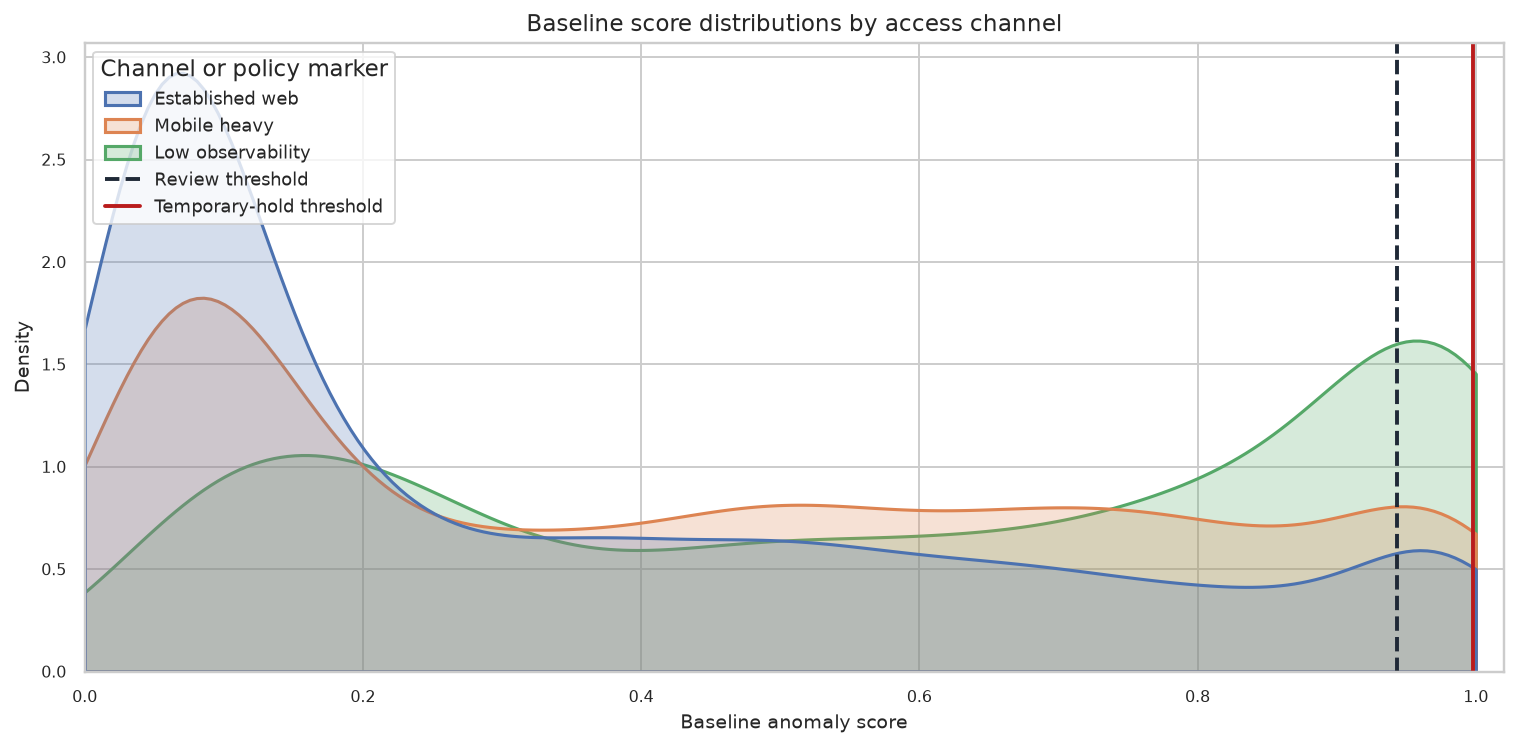

In [4]:
# Section focus: 5. Baseline Score and Baseline Policy.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.kdeplot(
    data=accounts,
    x='baseline_score',
    hue='access_channel',
    fill=True,
    common_norm=False,
    alpha=0.24,
    linewidth=1.6,
    clip=(0, 1),
    ax=ax,
)
ax.axvline(review_threshold, color='#1f2937', linestyle='--', linewidth=2, label='Review threshold')
ax.axvline(auto_threshold, color='#b91c1c', linestyle='-', linewidth=2, label='Temporary-hold threshold')
ax.set_title('Baseline score distributions by access channel')
ax.set_xlabel('Baseline anomaly score')
ax.set_ylabel('Density')
ax.set_xlim(0, 1.02)
handles, labels = ax.get_legend_handles_labels()
# Seaborn creates the channel legend; add explicit threshold handles.
threshold_handles = [
    Line2D([0], [0], color='#1f2937', linestyle='--', linewidth=2, label='Review threshold'),
    Line2D([0], [0], color='#b91c1c', linestyle='-', linewidth=2, label='Temporary-hold threshold'),
]
channel_handles = ax.legend_.legend_handles if ax.legend_ else []
channel_labels = [t.get_text() for t in ax.legend_.texts] if ax.legend_ else []
ax.legend(channel_handles + threshold_handles, channel_labels + ['Review threshold', 'Temporary-hold threshold'], title='Channel or policy marker', frameon=True, loc='upper left')
plt.tight_layout()
plt.show()

The low-observability distribution has a heavier right tail. That may reflect true incidents, measurement noise, or both. Governance begins by refusing to treat this tail as self-explanatory.

Treat this result as an alerting diagnostic. In Baseline Score and Baseline Policy, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. The point of this view is to turn unusual segments into root-cause leads.


## 6. Subgroup Diagnostics for the Baseline Policy

For anomaly detection, fairness diagnostics should focus on operational consequences: who is reviewed, who is held, who is falsely flagged, and who gets missed.

In [5]:
# Section focus: 6. Subgroup Diagnostics for the Baseline Policy.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def group_policy_metrics(df, action_col, label_col='true_incident', group_col='access_channel'):
    """Carry out the group policy metrics step used in the 16. Governance, Fairness, Privacy, and Human Review workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    action_col : object
        Column name indicating the action recommended by the decision rule.
    label_col : object
        Display setting used to make the plot or table readable in the rendered notebook.
    group_col : object
        Column name identifying the group or segment used for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for group, part in df.groupby(group_col):
        acted = part[action_col].ne('no_action')
        held = part[action_col].eq('temporary_hold')
        y = part[label_col].astype(int)
        fp = ((acted) & (y == 0)).sum()
        tn = ((~acted) & (y == 0)).sum()
        tp = ((acted) & (y == 1)).sum()
        fn = ((~acted) & (y == 1)).sum()
        rows.append({
            'access_channel': group,
            'cases': len(part),
            'population_share': len(part) / len(df),
            'alert_rate': acted.mean(),
            'temporary_hold_rate': held.mean(),
            'false_positive_rate': fp / max(fp + tn, 1),
            'true_positive_rate': tp / max(tp + fn, 1),
            'precision': tp / max(tp + fp, 1),
            'review_or_hold_share': acted.sum() / max(df[action_col].ne('no_action').sum(), 1),
            'confirmed_incident_share': tp / max(((df[action_col].ne('no_action')) & (df[label_col] == 1)).sum(), 1),
        })
    return pd.DataFrame(rows)

baseline_metrics = group_policy_metrics(accounts, 'baseline_action')
baseline_metrics.round(3)

,access_channel,cases,population_share,alert_rate,temporary_hold_rate,false_positive_rate,true_positive_rate,precision,review_or_hold_share,confirmed_incident_share
0,Established web,6405,0.534,0.066,0.006,0.004,0.689,0.941,0.352,0.385
1,Low observability,1856,0.155,0.228,0.061,0.074,0.912,0.736,0.353,0.302
2,Mobile heavy,3739,0.312,0.095,0.008,0.009,0.780,0.912,0.295,0.313


In Subgroup Diagnostics for the Baseline Policy, the detector earns its keep only if the output sharpens the review queue.


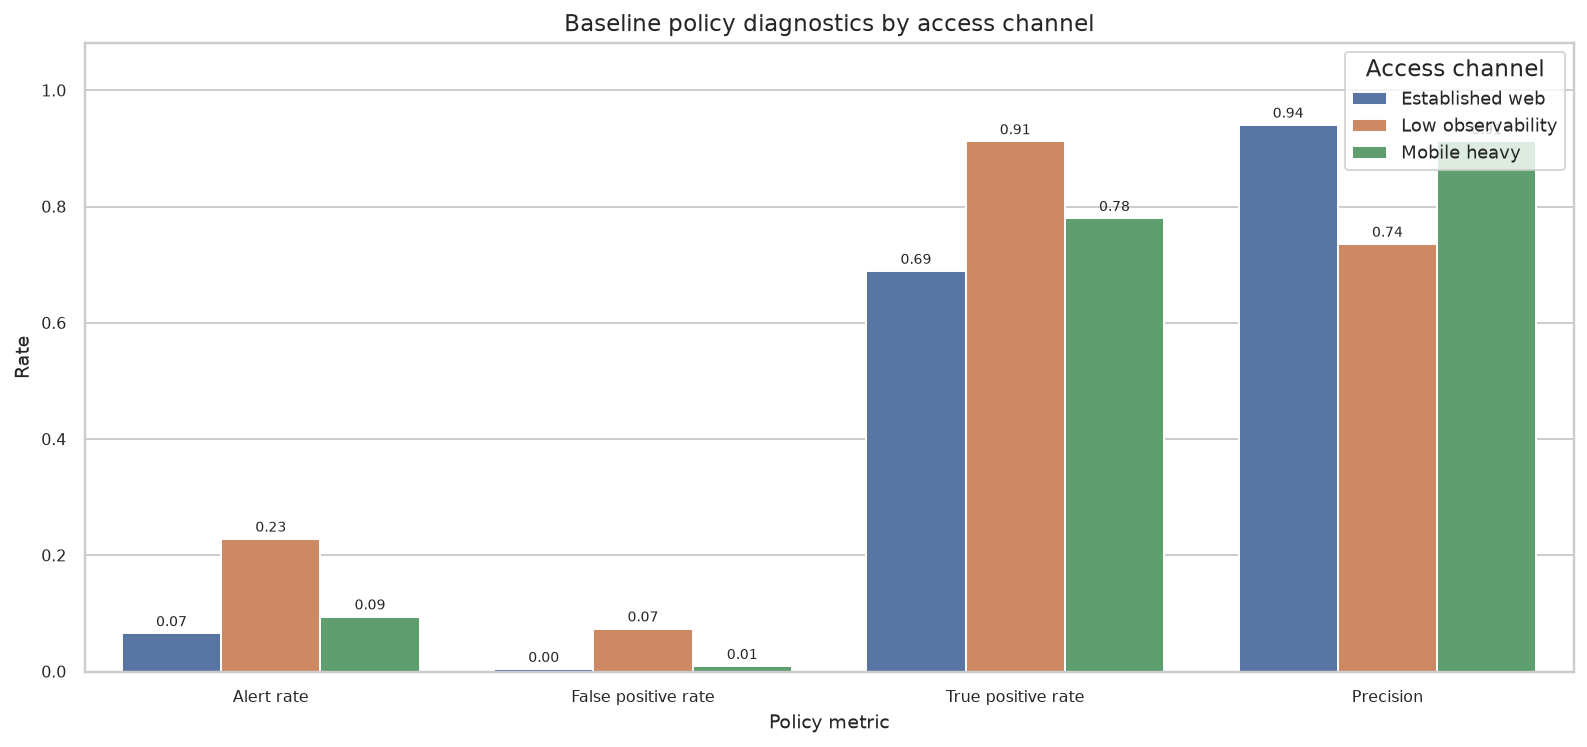

In [6]:
# Section focus: 6. Subgroup Diagnostics for the Baseline Policy.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

metric_long = baseline_metrics.melt(
    id_vars='access_channel',
    value_vars=['alert_rate', 'false_positive_rate', 'true_positive_rate', 'precision'],
    var_name='metric',
    value_name='value',
)
metric_labels = {
    'alert_rate': 'Alert rate',
    'false_positive_rate': 'False positive rate',
    'true_positive_rate': 'True positive rate',
    'precision': 'Precision',
}
metric_long['metric'] = metric_long['metric'].map(metric_labels)

fig, ax = plt.subplots(figsize=(11.5, 5.5))
sns.barplot(
    data=metric_long,
    x='metric',
    y='value',
    hue='access_channel',
    ax=ax,
)
ax.set_title('Baseline policy diagnostics by access channel')
ax.set_xlabel('Policy metric')
ax.set_ylabel('Rate')
ax.set_ylim(0, max(0.65, metric_long['value'].max() * 1.15))
ax.legend(title='Access channel', frameon=True, loc='upper right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

The plot should be read as a governance dashboard, not as a legal conclusion. It shows which groups carry more alert burden, which groups experience more false alarms, and whether those differences are justified by higher precision or recall.

The practical reading of Subgroup Diagnostics for the Baseline Policy is whether the flagged cases point to an action a team can defend.


## 7. Threshold Frontiers: Accuracy, Burden, and Capacity

Threshold choice is a governance decision. Lower thresholds increase detection but also increase review burden and false positives. We can inspect a threshold frontier before deciding policy.

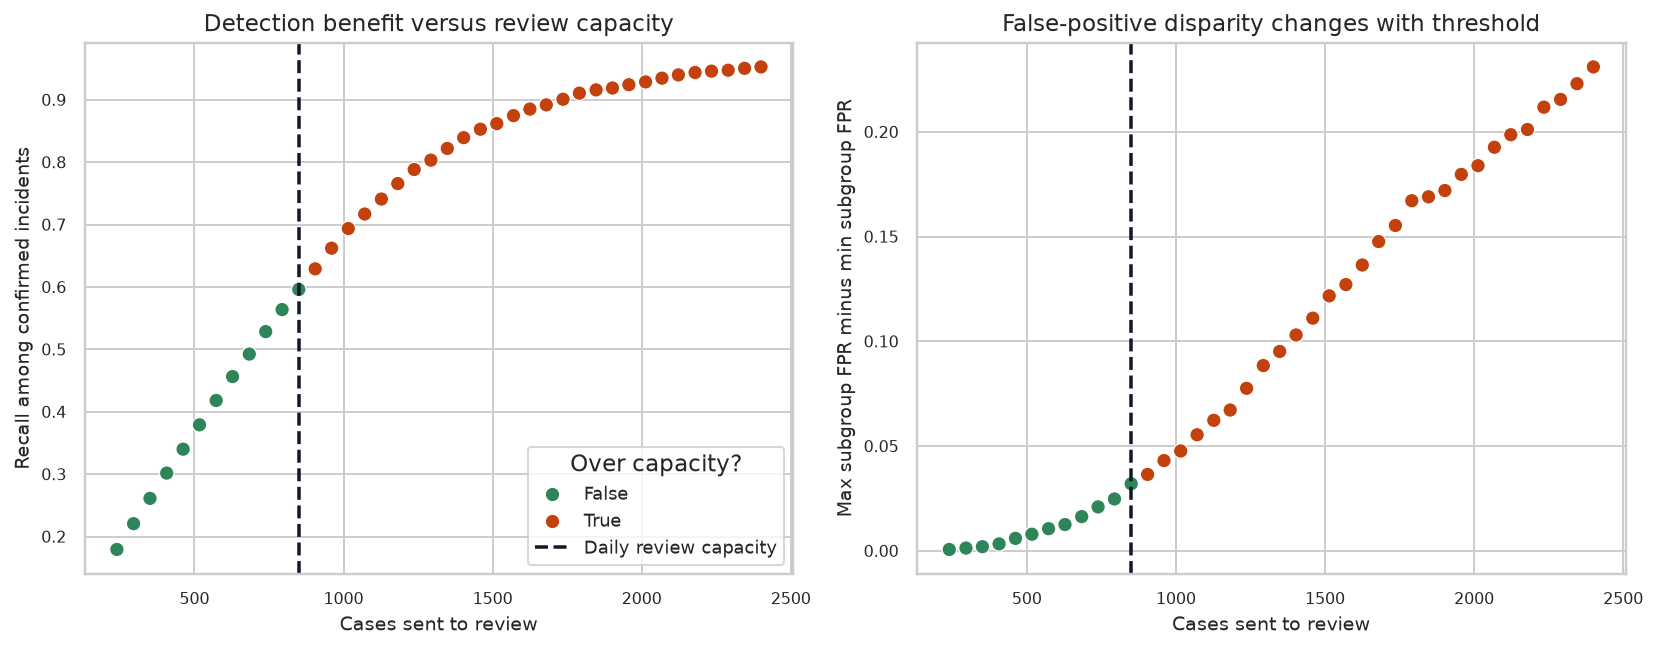

In [7]:
# Section focus: 7. Threshold Frontiers: Accuracy, Burden, and Capacity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def metrics_at_threshold(df, score_col, threshold):
    """Carry out the metrics at threshold step used in the 16. Governance, Fairness, Privacy, and Human Review workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    threshold : object
        Decision cutoff used to convert scores into actions or alerts.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    temp = df.copy()
    temp['action'] = np.where(temp[score_col] >= threshold, 'human_review', 'no_action')
    m = group_policy_metrics(temp, 'action')
    overall_acted = temp['action'].ne('no_action')
    y = temp['true_incident']
    tp = ((overall_acted) & (y == 1)).sum()
    fp = ((overall_acted) & (y == 0)).sum()
    fn = ((~overall_acted) & (y == 1)).sum()
    fpr_gap = m['false_positive_rate'].max() - m['false_positive_rate'].min()
    return {
        'threshold': threshold,
        'review_volume': overall_acted.sum(),
        'recall': tp / max(tp + fn, 1),
        'precision': tp / max(tp + fp, 1),
        'fpr_gap': fpr_gap,
        'low_observability_alert_rate': m.loc[m['access_channel'].eq('Low observability'), 'alert_rate'].iloc[0],
    }

threshold_grid = np.quantile(accounts['baseline_score'], np.linspace(0.80, 0.98, 40))
frontier = pd.DataFrame([metrics_at_threshold(accounts, 'baseline_score', t) for t in threshold_grid])
review_capacity = 850
frontier['over_capacity'] = frontier['review_volume'] > review_capacity

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.scatterplot(
    data=frontier,
    x='review_volume',
    y='recall',
    hue='over_capacity',
    palette={False: '#2f855a', True: '#c2410c'},
    s=55,
    ax=axes[0],
)
axes[0].axvline(review_capacity, color='#111827', linestyle='--', linewidth=1.8, label='Daily review capacity')
axes[0].set_title('Detection benefit versus review capacity')
axes[0].set_xlabel('Cases sent to review')
axes[0].set_ylabel('Recall among confirmed incidents')
axes[0].legend(title='Over capacity?', frameon=True)

sns.scatterplot(
    data=frontier,
    x='review_volume',
    y='fpr_gap',
    hue='over_capacity',
    palette={False: '#2f855a', True: '#c2410c'},
    s=55,
    ax=axes[1],
    legend=False,
)
axes[1].axvline(review_capacity, color='#111827', linestyle='--', linewidth=1.8)
axes[1].set_title('False-positive disparity changes with threshold')
axes[1].set_xlabel('Cases sent to review')
axes[1].set_ylabel('Max subgroup FPR minus min subgroup FPR')
plt.tight_layout()
plt.show()

The frontier turns threshold choice into an explicit tradeoff. If a threshold sends more cases than analysts can review, the operational policy is already broken even if the detector has a strong statistical score.

Read Threshold Frontiers: Accuracy, Burden, and Capacity as an alert-design check. The output should help the reviewer decide what to investigate, suppress, monitor, or revise.


## 8. A Governed Policy: Measurement-Aware Score, Guardrails, and Capacity

Now create a governed variant. It does three things:

1. Reduces weight on location and proxy signals that are privacy-sensitive and noisy for some channels.
2. Requires multiple independent evidence signals before automatic temporary holds.
3. Caps the human review queue and prevents one channel from consuming a disproportionate share of limited review capacity unless evidence remains strong.

This is not the only governance design. It is a concrete design that can be audited.

In [8]:
# Section focus: 8. A Governed Policy: Measurement-Aware Score, Guardrails, and Capacity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

accounts['governed_score'] = sigmoid(
    -2.55
    + 0.62 * accounts['login_velocity_z']
    + 0.48 * accounts['failed_login_count_z']
    + 0.28 * accounts['device_churn_z']
    + 0.22 * accounts['geo_distance_km_z']
    + 0.30 * accounts['proxy_network']
    + 0.34 * accounts['night_activity']
    + 0.70 * accounts['prior_chargeback']
    + 0.40 * accounts['spend_deviation_z']
    + 0.22 * accounts['evidence_count']
)

accounts['governed_action'] = 'no_action'

governed_auto_threshold = accounts['governed_score'].quantile(0.990)
auto_guard = (accounts['governed_score'] >= governed_auto_threshold) & (accounts['evidence_count'] >= 4)
accounts.loc[auto_guard, 'governed_action'] = 'temporary_hold'

review_capacity = 850
already_auto = accounts['governed_action'].eq('temporary_hold')
review_pool = accounts.loc[~already_auto].copy().sort_values('governed_score', ascending=False)

population_share = accounts['access_channel'].value_counts(normalize=True).to_dict()
max_review_share_multiplier = 1.35
review_caps = {
    group: int(np.ceil(review_capacity * share * max_review_share_multiplier))
    for group, share in population_share.items()
}

selected = []
selected_by_group = {group: 0 for group in population_share}
for idx, row in review_pool.iterrows():
    if len(selected) >= review_capacity:
        break
    group = row['access_channel']
    if selected_by_group[group] < review_caps[group]:
        selected.append(idx)
        selected_by_group[group] += 1

# Fill leftover capacity, if any, by score after the cap pass.
if len(selected) < review_capacity:
    remaining = [idx for idx in review_pool.index if idx not in selected]
    selected.extend(remaining[: review_capacity - len(selected)])

accounts.loc[selected, 'governed_action'] = 'human_review'

governed_policy_summary = pd.DataFrame([
    {'quantity': 'Governed temporary-hold threshold', 'value': governed_auto_threshold},
    {'quantity': 'Temporary holds after evidence guardrail', 'value': int(auto_guard.sum())},
    {'quantity': 'Human review capacity', 'value': review_capacity},
    {'quantity': 'Human review cases selected', 'value': int(accounts['governed_action'].eq('human_review').sum())},
    {'quantity': 'Review cap multiplier by population share', 'value': max_review_share_multiplier},
    {'quantity': 'Overall precision among acted cases', 'value': accounts.loc[accounts['governed_action'].ne('no_action'), 'true_incident'].mean()},
])
governed_policy_summary

,quantity,value
0,Governed temporary-hold threshold,0.998976
1,Temporary holds after evidence guardrail,83.000000
2,Human review capacity,850.000000
3,Human review cases selected,850.000000
4,Review cap multiplier by population share,1.350000
5,Overall precision among acted cases,0.937835


The practical test in A Governed Policy: Measurement-Aware Score, Guardrails, and Capacity is whether the result would improve review quality. A good alert separates actionable risk from background noise and expected seasonal movement.


In [9]:
governed_metrics = group_policy_metrics(accounts, 'governed_action')
comparison_metrics = pd.concat(
    [
        baseline_metrics.assign(policy='Baseline score and thresholds'),
        governed_metrics.assign(policy='Governed score and queue'),
    ],
    ignore_index=True,
)
comparison_metrics.round(3)

,access_channel,cases,population_share,alert_rate,temporary_hold_rate,false_positive_rate,true_positive_rate,precision,review_or_hold_share,confirmed_incident_share,policy
0,Established web,6405,0.534,0.066,0.006,0.004,0.689,0.941,0.352,0.385,Baseline score and thresholds
1,Low observability,1856,0.155,0.228,0.061,0.074,0.912,0.736,0.353,0.302,Baseline score and thresholds
2,Mobile heavy,3739,0.312,0.095,0.008,0.009,0.780,0.912,0.295,0.313,Baseline score and thresholds
3,Established web,6405,0.534,0.061,0.003,0.005,0.632,0.931,0.419,0.416,Governed score and queue
4,Low observability,1856,0.155,0.120,0.024,0.005,0.632,0.969,0.239,0.247,Governed score and queue
5,Mobile heavy,3739,0.312,0.085,0.005,0.007,0.713,0.925,0.342,0.337,Governed score and queue


Read the result through the lens of alert quality. In A Governed Policy: Measurement-Aware Score, Guardrails, and Capacity, high scores, unusual clusters, or shifted distributions should be connected to the cost of missed incidents and false alarms. A useful detector is one whose outputs can be investigated, explained, and governed.


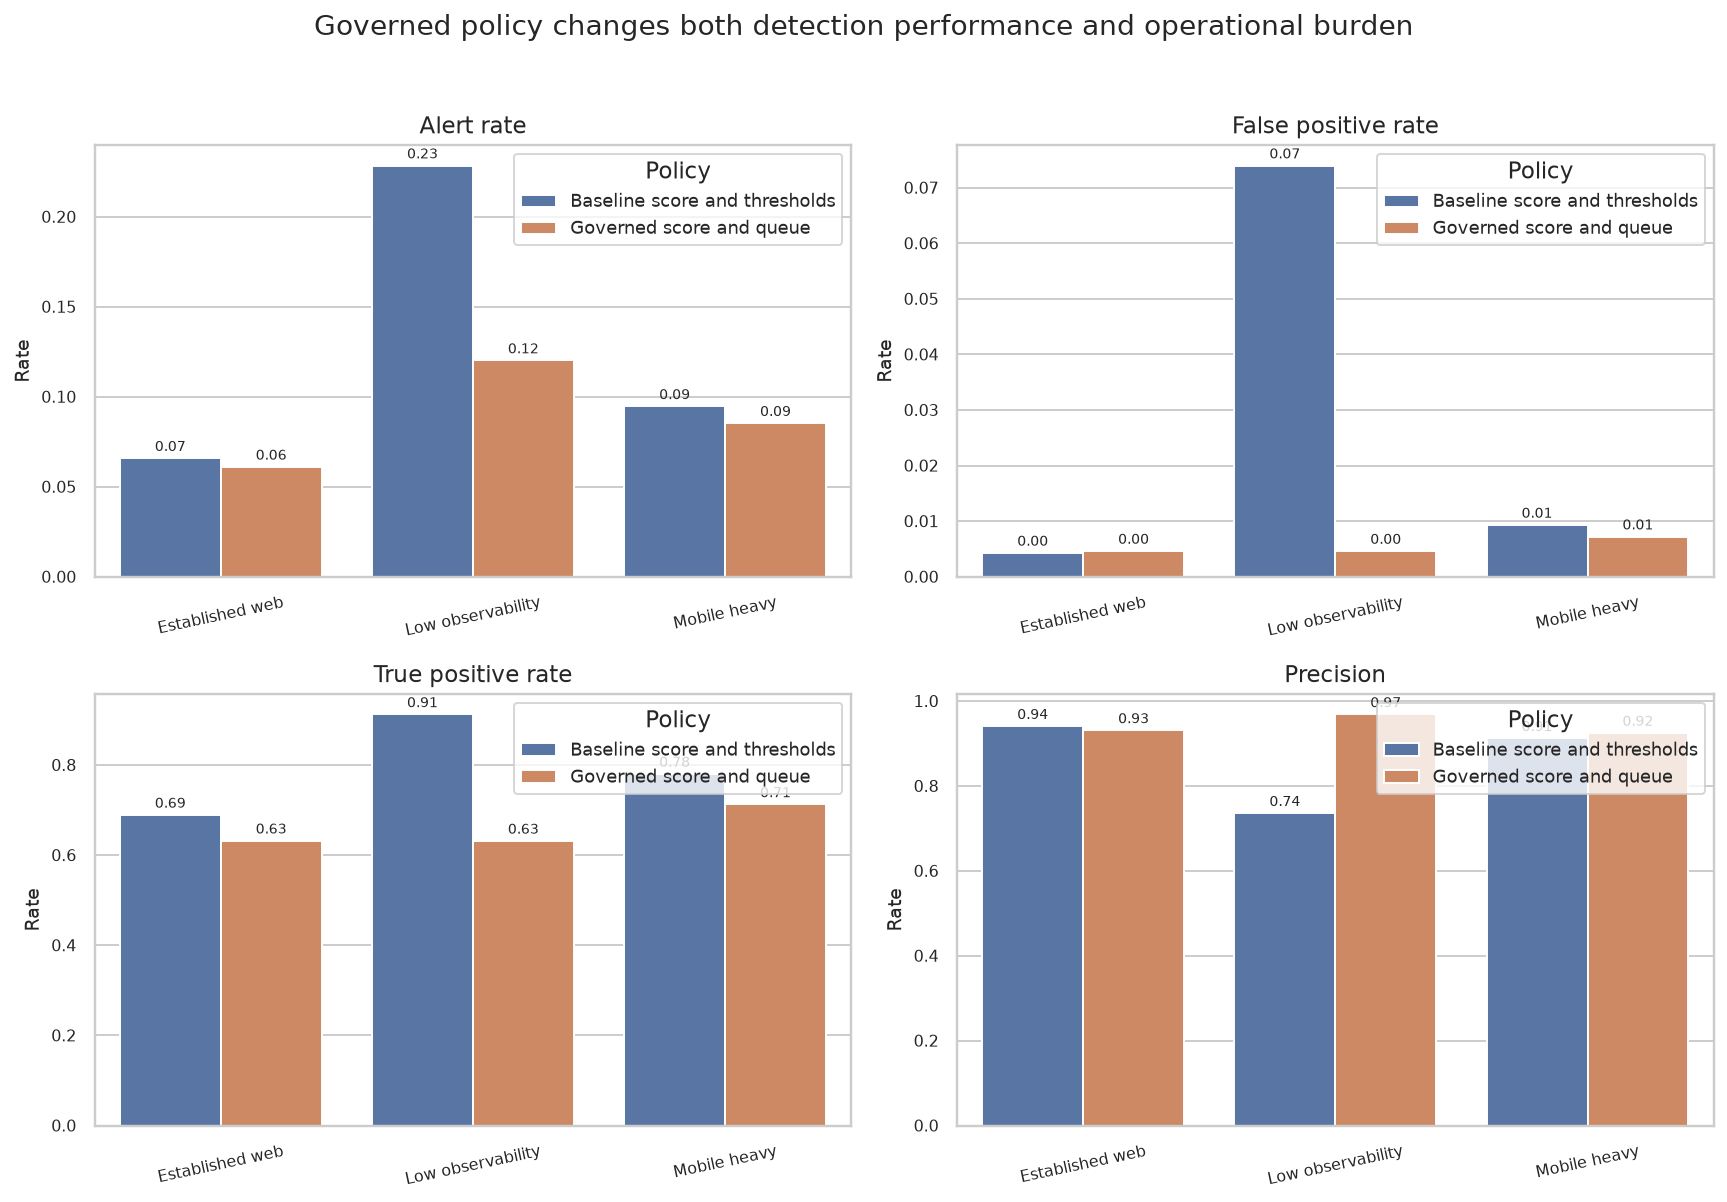

In [10]:
plot_metrics = comparison_metrics.melt(
    id_vars=['policy', 'access_channel'],
    value_vars=['alert_rate', 'false_positive_rate', 'true_positive_rate', 'precision'],
    var_name='metric',
    value_name='value',
)
plot_metrics['metric'] = plot_metrics['metric'].map(metric_labels)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.4), sharey=False)
axes = axes.ravel()
for ax, metric in zip(axes, ['Alert rate', 'False positive rate', 'True positive rate', 'Precision']):
    subset = plot_metrics.query('metric == @metric')
    sns.barplot(data=subset, x='access_channel', y='value', hue='policy', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_ylabel('Rate')
    ax.tick_params(axis='x', rotation=12)
    ax.legend(title='Policy', frameon=True, loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.suptitle('Governed policy changes both detection performance and operational burden', y=1.02)
plt.tight_layout()
plt.show()

A governed policy may reduce false positive disparity, but it can also alter recall and precision. That tradeoff must be explicit. Governance is not free; it is a design choice about which risks are acceptable and which require guardrails.

For A Governed Policy: Measurement-Aware Score, Guardrails, and Capacity, the important question is whether the result changes triage. A useful output makes the next investigation clearer.


## 9. Review Queue Composition and Human Workload

A human review queue is a scarce resource. We should compare review burden against population share and confirmed-incident share.

In [11]:
# Section focus: 9. Review Queue Composition and Human Workload.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def queue_composition(df, action_col):
    """Carry out the queue composition step used in the 16. Governance, Fairness, Privacy, and Human Review workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    action_col : object
        Column name indicating the action recommended by the decision rule.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    acted = df[df[action_col].ne('no_action')]
    confirmed_acted = acted[acted['true_incident'].eq(1)]
    rows = []
    for group, part in df.groupby('access_channel'):
        rows.append({
            'access_channel': group,
            'population_share': len(part) / len(df),
            'review_or_hold_share': (acted['access_channel'].eq(group)).mean() if len(acted) else 0,
            'confirmed_incident_share_among_acted': (confirmed_acted['access_channel'].eq(group)).mean() if len(confirmed_acted) else 0,
        })
    return pd.DataFrame(rows)

queue_compare = pd.concat([
    queue_composition(accounts, 'baseline_action').assign(policy='Baseline'),
    queue_composition(accounts, 'governed_action').assign(policy='Governed'),
])
queue_compare.round(3)

,access_channel,population_share,review_or_hold_share,confirmed_incident_share_among_acted,policy
0,Established web,0.534,0.352,0.385,Baseline
1,Low observability,0.155,0.353,0.302,Baseline
2,Mobile heavy,0.312,0.295,0.313,Baseline
0,Established web,0.534,0.419,0.416,Governed
1,Low observability,0.155,0.239,0.247,Governed
2,Mobile heavy,0.312,0.342,0.337,Governed


Treat this result as an alerting diagnostic. In Review Queue Composition and Human Workload, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. If the pattern is concentrated, the next review should start there.


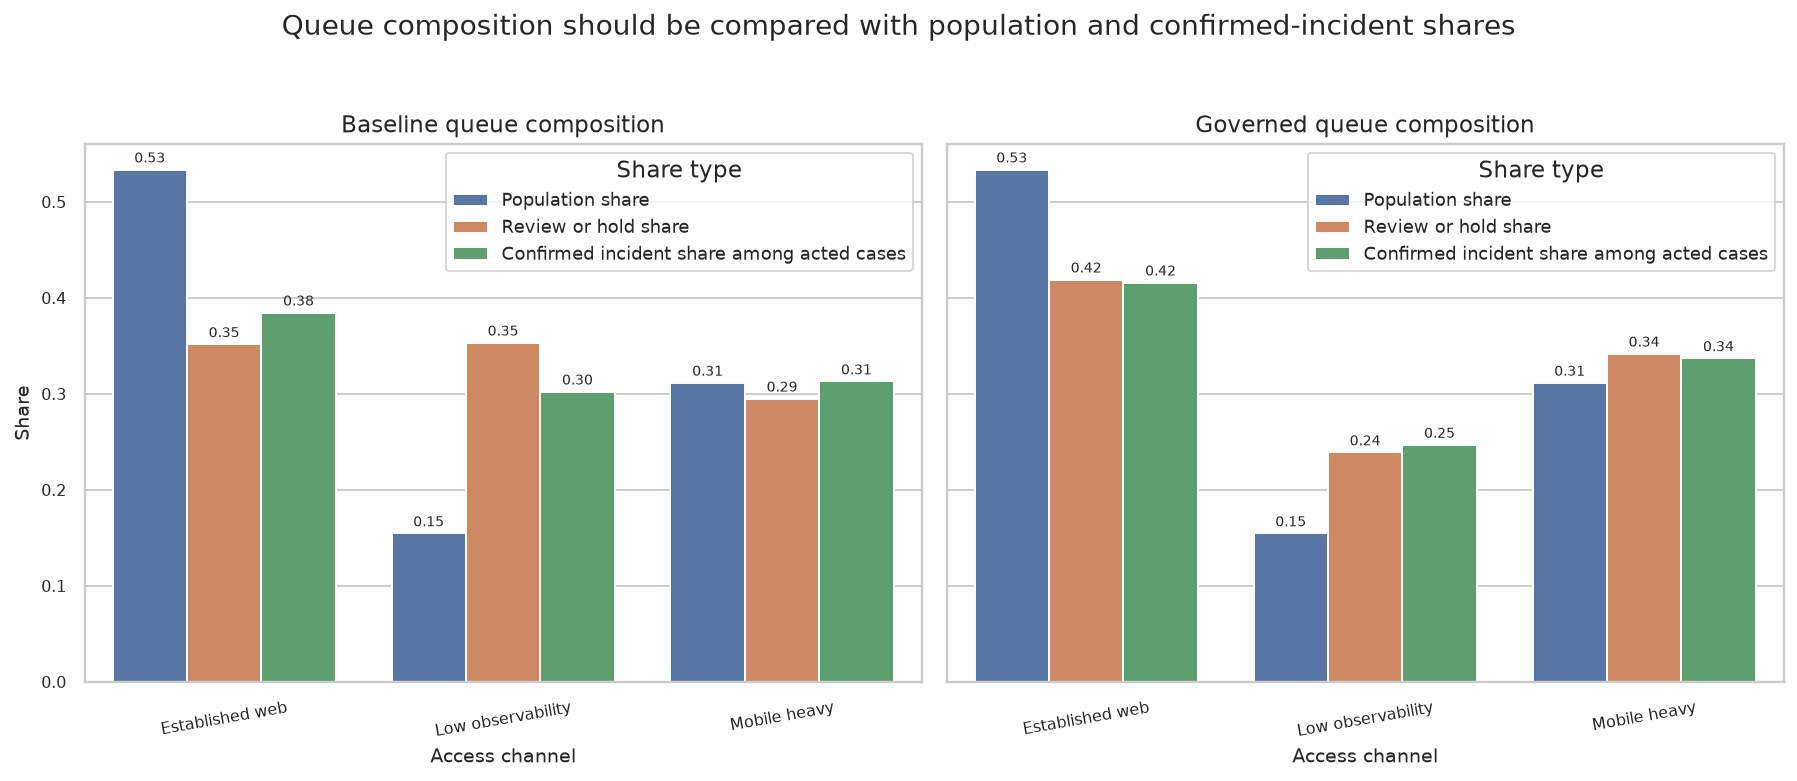

In [12]:
# Section focus: 9. Review Queue Composition and Human Workload.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

queue_long = queue_compare.melt(
    id_vars=['policy', 'access_channel'],
    value_vars=['population_share', 'review_or_hold_share', 'confirmed_incident_share_among_acted'],
    var_name='share_type',
    value_name='share',
)
share_labels = {
    'population_share': 'Population share',
    'review_or_hold_share': 'Review or hold share',
    'confirmed_incident_share_among_acted': 'Confirmed incident share among acted cases',
}
queue_long['share_type'] = queue_long['share_type'].map(share_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
for ax, policy in zip(axes, ['Baseline', 'Governed']):
    subset = queue_long.query('policy == @policy')
    sns.barplot(
        data=subset,
        x='access_channel',
        y='share',
        hue='share_type',
        errorbar=None,
        ax=ax,
    )
    ax.set_title(f'{policy} queue composition')
    ax.set_xlabel('Access channel')
    ax.set_ylabel('Share' if ax is axes[0] else '')
    ax.tick_params(axis='x', rotation=10)
    ax.legend(title='Share type', frameon=True, loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.suptitle('Queue composition should be compared with population and confirmed-incident shares', y=1.03)
plt.tight_layout()
plt.show()

The goal is not to force every share to be identical. The goal is to make deviations explainable. If a group receives a much larger share of reviews than its population share, the system should show whether that burden is supported by confirmed incidents or driven by noisy proxies.

## 10. Privacy: Data Minimization and Noisy Aggregate Monitoring

Privacy concerns names, account IDs, location, device fingerprints, proxy use, timestamps, and behavior trails. Location, device fingerprints, proxy use, timestamps, and behavior trails can become identifying when combined.

Differential privacy formalizes one way to protect aggregate analysis. A randomized mechanism $M$ is $(\epsilon, \delta)$-differentially private if for neighboring datasets $D$ and $D'$ that differ in one individual, and any output set $S$,

$$
\Pr[M(D) \in S] \leq e^\epsilon \Pr[M(D') \in S] + \delta.
$$

For a count query $q(D)$ with sensitivity $\Delta q = 1$, the Laplace mechanism releases

$$
M(D) = q(D) + \mathrm{Laplace}\left(0, \frac{1}{\epsilon}\right).
$$

In this notebook we use noisy aggregate counts for monitoring. We do **not** use noise to hide row-level decisions from reviewers, because investigators need reliable case evidence. Privacy controls must match the workflow.

In [13]:
# Section focus: 10. Privacy: Data Minimization and Noisy Aggregate Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def laplace_noisy_count(count, epsilon, rng):
    """Carry out the laplace noisy count step used in the 16. Governance, Fairness, Privacy, and Human Review workflow.
    
    Parameters
    ----------
    count : object
        Count or size parameter controlling the scale of the simulation or calculation.
    epsilon : object
        The epsilon setting that controls the laplace noisy count calculation in this notebook.
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the laplace noisy count calculation.
    """
    return count + rng.laplace(loc=0, scale=1 / epsilon)

true_counts = (
    accounts.assign(acted=accounts['governed_action'].ne('no_action'))
    .groupby('access_channel')['acted']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'acted_count', 'count': 'cases'})
    .reset_index()
)
true_counts['true_alert_rate'] = true_counts['acted_count'] / true_counts['cases']

epsilons = [0.2, 0.5, 1.0, 2.0, 5.0]
privacy_rows = []
for eps in epsilons:
    for _ in range(400):
        for _, row in true_counts.iterrows():
            noisy_acted = laplace_noisy_count(row['acted_count'], eps, rng)
            noisy_cases = laplace_noisy_count(row['cases'], eps, rng)
            noisy_rate = np.clip(noisy_acted / max(noisy_cases, 1), 0, 1)
            privacy_rows.append({
                'epsilon': eps,
                'access_channel': row['access_channel'],
                'absolute_rate_error': abs(noisy_rate - row['true_alert_rate']),
            })
privacy_df = pd.DataFrame(privacy_rows)
privacy_summary = (
    privacy_df.groupby(['epsilon', 'access_channel'])['absolute_rate_error']
    .mean()
    .reset_index()
)
privacy_summary.head(10).round(4)

,epsilon,access_channel,absolute_rate_error
0,0.2,Established web,0.0008
1,0.2,Low observability,0.0028
2,0.2,Mobile heavy,0.0013
3,0.5,Established web,0.0003
4,0.5,Low observability,0.0010
5,0.5,Mobile heavy,0.0005
6,1.0,Established web,0.0002
7,1.0,Low observability,0.0006
8,1.0,Mobile heavy,0.0003
9,2.0,Established web,0.0001


For Privacy: Data Minimization and Noisy Aggregate Monitoring, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


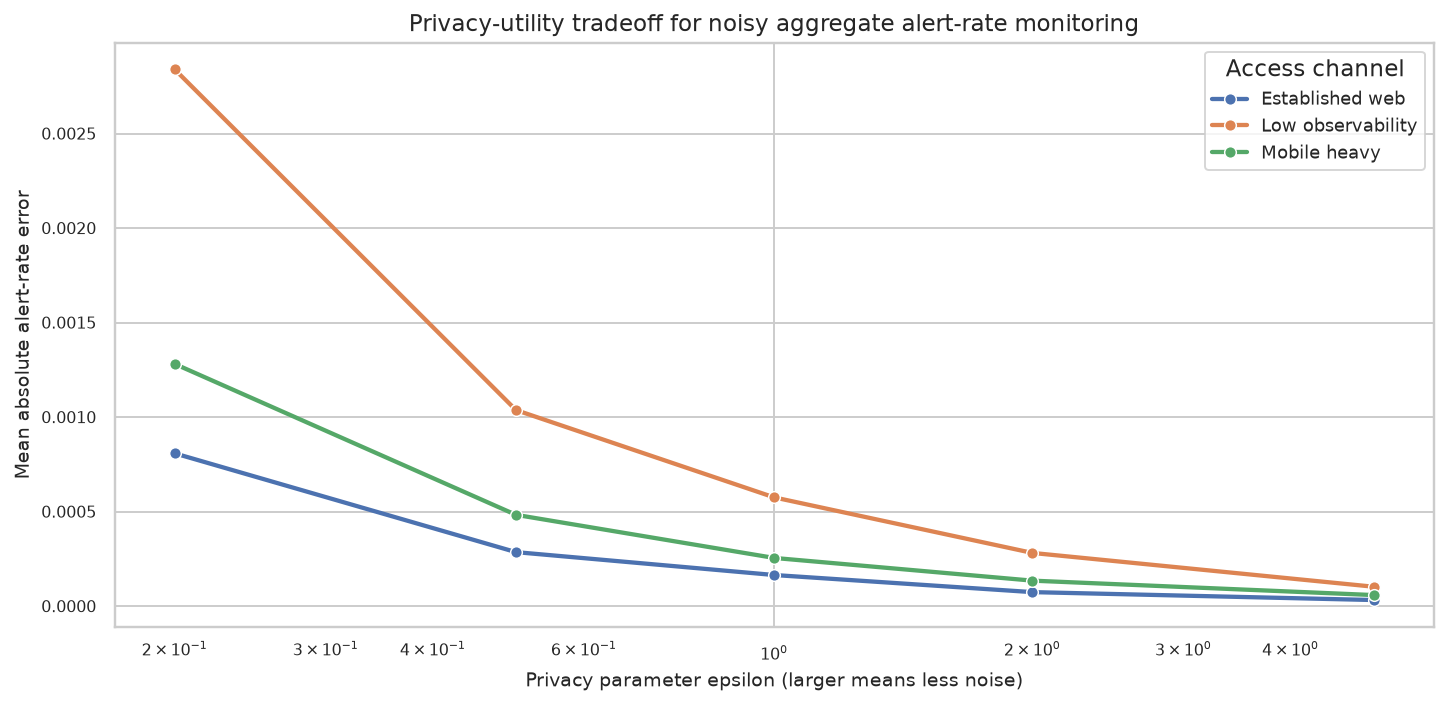

In [14]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.lineplot(
    data=privacy_summary,
    x='epsilon',
    y='absolute_rate_error',
    hue='access_channel',
    marker='o',
    linewidth=2.2,
    ax=ax,
)
ax.set_xscale('log')
ax.set_title('Privacy-utility tradeoff for noisy aggregate alert-rate monitoring')
ax.set_xlabel('Privacy parameter epsilon (larger means less noise)')
ax.set_ylabel('Mean absolute alert-rate error')
ax.legend(title='Access channel', frameon=True)
plt.tight_layout()
plt.show()

The smaller the privacy parameter, the noisier the released aggregate. This is a feature, not a bug: the mechanism protects individual participation at the cost of less precise aggregate monitoring. Governance must decide which dashboards need exact values and which can use noisy aggregates.

Privacy: Data Minimization and Noisy Aggregate Monitoring is less about the score itself and more about whether the score creates an actionable investigation path.


## 11. Audit Records: Minimum Useful Evidence

An audit record should be useful enough for accountability but sparse enough to avoid unnecessary exposure.

| Field | Keep? | Reason |
|---|---:|---|
| Salted case identifier | Yes | Allows traceability without exposing direct account ID |
| Score version and threshold version | Yes | Reconstructs why the action happened |
| Action taken | Yes | Required for accountability |
| Evidence family flags | Yes | Explains broad reason categories |
| Raw IP address | No | High privacy risk and rarely needed in the governance layer |
| Exact location trail | No | Use coarse risk bucket instead |
| Reviewer ID | Limited | Needed for audit, access-controlled |
| Reviewer decision and rationale code | Yes | Needed to evaluate overrides and learning |
| Retention deadline | Yes | Prevents permanent accumulation of sensitive cases |

In [15]:
# Section focus: 11. Audit Records: Minimum Useful Evidence.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

audited_cases = accounts.loc[accounts['governed_action'].ne('no_action')].copy()
audited_cases = audited_cases.sort_values('governed_score', ascending=False).head(8)

audit_log = pd.DataFrame({
    'audit_case_id': [f'audit_{i:04d}' for i in range(len(audited_cases))],
    'score_version': 'acct-risk-v2.1-governed',
    'threshold_version': 'policy-2026-03',
    'action': audited_cases['governed_action'].to_numpy(),
    'score_bucket': pd.cut(
        audited_cases['governed_score'],
        bins=[0, 0.65, 0.80, 0.90, 1.0],
        labels=['low', 'medium', 'high', 'critical'],
        include_lowest=True,
    ).astype(str).to_numpy(),
    'evidence_count': audited_cases['evidence_count'].to_numpy(),
    'coarse_channel': audited_cases['access_channel'].to_numpy(),
    'location_risk_bucket': pd.cut(
        audited_cases['geo_distance_km'],
        bins=[0, 250, 750, 1500, np.inf],
        labels=['near', 'moderate', 'far', 'extreme'],
        include_lowest=True,
    ).astype(str).to_numpy(),
    'review_rationale_code': np.where(audited_cases['governed_action'].eq('temporary_hold'), 'auto_guardrail_met', 'pending_review'),
    'retention_days': np.where(audited_cases['governed_action'].eq('temporary_hold'), 180, 90),
})

audit_log

,audit_case_id,score_version,threshold_version,action,score_bucket,evidence_count,coarse_channel,location_risk_bucket,review_rationale_code,retention_days
0,audit_0000,acct-risk-v2.1-governed,policy-2026-03,temporary_hold,critical,5,Low observability,far,auto_guardrail_met,180
1,audit_0001,acct-risk-v2.1-governed,policy-2026-03,temporary_hold,critical,4,Low observability,far,auto_guardrail_met,180
2,audit_0002,acct-risk-v2.1-governed,policy-2026-03,human_review,critical,3,Established web,extreme,pending_review,90
3,audit_0003,acct-risk-v2.1-governed,policy-2026-03,temporary_hold,critical,4,Established web,near,auto_guardrail_met,180
4,audit_0004,acct-risk-v2.1-governed,policy-2026-03,human_review,critical,3,Mobile heavy,far,pending_review,90
5,audit_0005,acct-risk-v2.1-governed,policy-2026-03,temporary_hold,critical,5,Low observability,extreme,auto_guardrail_met,180
6,audit_0006,acct-risk-v2.1-governed,policy-2026-03,temporary_hold,critical,5,Low observability,far,auto_guardrail_met,180
7,audit_0007,acct-risk-v2.1-governed,policy-2026-03,temporary_hold,critical,5,Low observability,far,auto_guardrail_met,180


The audit log is not a data dump. It is a deliberately minimized record that supports accountability, monitoring, and post-incident learning while reducing exposure of raw sensitive telemetry.

Read Audit Records: Minimum Useful Evidence with the reviewer in mind. A useful anomaly score improves triage.


## 12. Human Review and Override Monitoring

Human review is a design component. It can improve outcomes, but only if reviewers have enough context, enough time, and a clear override protocol.

A review workflow should track:

| Review measure | Why it matters |
|---|---|
| Review volume per analyst | Detects fatigue and queue overload |
| Confirmation rate by subgroup | Detects unequal false alert burden |
| Reviewer release/monitor rate by queue-priority band | Finds score ranges where the model is unreliable |
| Time to decision | Measures customer or operational harm from waiting |
| Reason-code distribution | Feeds model improvement and policy revision |

In [16]:
# Section focus: 12. Human Review and Override Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

reviewed = accounts.loc[accounts['governed_action'].eq('human_review')].copy()
reviewed = reviewed.sort_values('governed_score', ascending=False).reset_index(drop=True)

# Simulate review outcomes for demonstration. Real systems would use actual reviewer labels.
reviewed['reviewer_confirms_incident'] = np.where(
    reviewed['true_incident'].eq(1),
    rng.binomial(1, 0.90, size=len(reviewed)),
    rng.binomial(1, 0.08 + 0.08 * (reviewed['evidence_count'] >= 4), size=len(reviewed)),
)
reviewed['queue_priority_band'] = pd.qcut(
    reviewed['governed_score'].rank(method='first'),
    q=4,
    labels=['Lower queue', 'Middle queue', 'High queue', 'Top queue'],
)
reviewed['model_suggested_action'] = np.where(reviewed['governed_score'] >= governed_auto_threshold, 'temporary_hold', 'review')
reviewed['reviewer_final_action'] = np.where(reviewed['reviewer_confirms_incident'].eq(1), 'temporary_hold_or_escalate', 'release_or_monitor')
reviewed['reviewer_release_or_monitor'] = reviewed['reviewer_final_action'].eq('release_or_monitor')

review_summary = (
    reviewed.groupby(['access_channel', 'queue_priority_band'], observed=True)
    .agg(
        reviewed_cases=('case_id', 'count'),
        confirmation_rate=('reviewer_confirms_incident', 'mean'),
        release_or_monitor_rate=('reviewer_release_or_monitor', 'mean'),
    )
    .reset_index()
)
review_summary.round(3).head(12)

,access_channel,queue_priority_band,reviewed_cases,confirmation_rate,release_or_monitor_rate
0,Established web,Lower queue,127,0.764,0.236
1,Established web,Middle queue,91,0.868,0.132
2,Established web,High queue,79,0.823,0.177
3,Established web,Top queue,74,0.892,0.108
4,Low observability,Middle queue,53,0.830,0.170
5,Low observability,High queue,63,0.889,0.111
6,Low observability,Top queue,62,0.935,0.065
7,Mobile heavy,Lower queue,86,0.733,0.267
8,Mobile heavy,Middle queue,68,0.809,0.191
9,Mobile heavy,High queue,70,0.943,0.057


Treat this result as an alerting diagnostic. In Human Review and Override Monitoring, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. The practical value is in showing where triage should begin.


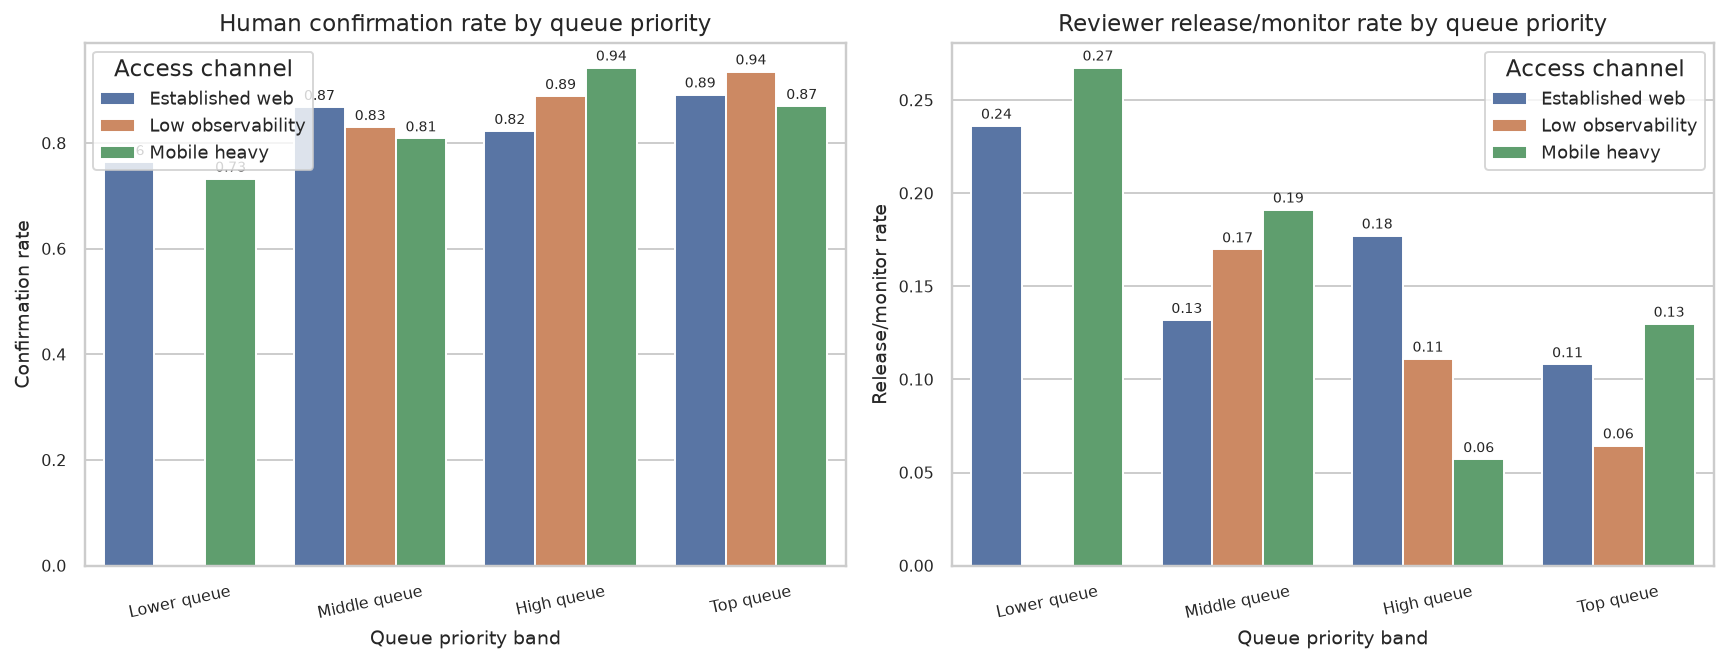

In [17]:
# Section focus: 12. Human Review and Override Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

priority_order = ['Lower queue', 'Middle queue', 'High queue', 'Top queue']
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))

sns.barplot(
    data=review_summary,
    x='queue_priority_band',
    y='confirmation_rate',
    hue='access_channel',
    order=priority_order,
    ax=axes[0],
)
axes[0].set_title('Human confirmation rate by queue priority')
axes[0].set_xlabel('Queue priority band')
axes[0].set_ylabel('Confirmation rate')
axes[0].legend(title='Access channel', frameon=True, loc='upper left')
axes[0].tick_params(axis='x', rotation=12)

sns.barplot(
    data=review_summary,
    x='queue_priority_band',
    y='release_or_monitor_rate',
    hue='access_channel',
    order=priority_order,
    ax=axes[1],
)
axes[1].set_title('Reviewer release/monitor rate by queue priority')
axes[1].set_xlabel('Queue priority band')
axes[1].set_ylabel('Release/monitor rate')
axes[1].legend(title='Access channel', frameon=True, loc='upper right')
axes[1].tick_params(axis='x', rotation=12)

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

If release/monitor rates are concentrated in one subgroup, that is a signal to revisit feature definitions, thresholding, reviewer instructions, or upstream data quality. Human review should create feedback for governance while cleaning up model mistakes one case at a time.

Treat this result as an alerting diagnostic. In Human Review and Override Monitoring, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. A concentrated pattern should guide the first root-cause check.


## 13. Governance Decision Memo

The final product of governance analysis is a decision memo. It is a decision memo that says what policy is allowed, what is prohibited, and what will be monitored.

In [18]:
base_fpr_gap = baseline_metrics['false_positive_rate'].max() - baseline_metrics['false_positive_rate'].min()
gov_fpr_gap = governed_metrics['false_positive_rate'].max() - governed_metrics['false_positive_rate'].min()
base_precision = accounts.loc[accounts['baseline_action'].ne('no_action'), 'true_incident'].mean()
gov_precision = accounts.loc[accounts['governed_action'].ne('no_action'), 'true_incident'].mean()
base_volume = accounts['baseline_action'].ne('no_action').sum()
gov_volume = accounts['governed_action'].ne('no_action').sum()

display(Markdown(f'''
### Recommended Policy

Move from the baseline score to the governed score and queue policy for account-risk alerts.

### Evidence

- Baseline review-or-hold volume: **{base_volume:,}** cases.
- Governed review-or-hold volume: **{gov_volume:,}** cases, aligned with daily review capacity of **{review_capacity:,}** human reviews plus guarded automatic holds.
- Baseline precision among acted cases: **{base_precision:.2%}**.
- Governed precision among acted cases: **{gov_precision:.2%}**.
- Baseline subgroup FPR gap: **{base_fpr_gap:.3f}**.
- Governed subgroup FPR gap: **{gov_fpr_gap:.3f}**.

### Guardrails

1. No automatic temporary hold unless the governed score is above the high threshold and at least four independent evidence families are active.
2. Review queues must be capped by analyst capacity and monitored for subgroup burden.
3. Raw location and network identifiers should not appear in governance dashboards; use coarse risk buckets and access-controlled case tools.
4. Aggregate subgroup monitoring can use noisy counts when reports leave the restricted analytics environment.
5. Release/monitor rates, confirmation rates, and subgroup false positive rates should be reviewed every policy cycle.

### Conditions for Revision

Revise thresholds or feature weights if low-observability users show rising release/monitor rates among top-priority cases, if the review queue exceeds capacity, if confirmed incident recall falls below business tolerance, or if data collection changes make current score components obsolete.
'''))


### Recommended Policy

Move from the baseline score to the governed score and queue policy for account-risk alerts.

### Evidence

- Baseline review-or-hold volume: **1,200** cases.
- Governed review-or-hold volume: **933** cases, aligned with daily review capacity of **850** human reviews plus guarded automatic holds.
- Baseline precision among acted cases: **86.00%**.
- Governed precision among acted cases: **93.78%**.
- Baseline subgroup FPR gap: **0.070**.
- Governed subgroup FPR gap: **0.003**.

### Guardrails

1. No automatic temporary hold unless the governed score is above the high threshold and at least four independent evidence families are active.
2. Review queues must be capped by analyst capacity and monitored for subgroup burden.
3. Raw location and network identifiers should not appear in governance dashboards; use coarse risk buckets and access-controlled case tools.
4. Aggregate subgroup monitoring can use noisy counts when reports leave the restricted analytics environment.
5. Release/monitor rates, confirmation rates, and subgroup false positive rates should be reviewed every policy cycle.

### Conditions for Revision

Revise thresholds or feature weights if low-observability users show rising release/monitor rates among top-priority cases, if the review queue exceeds capacity, if confirmed incident recall falls below business tolerance, or if data collection changes make current score components obsolete.


In Governance Decision Memo, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


## 14. Practical Checklist

Before deploying an anomaly detector that affects people, accounts, or sensitive operations, ask:

| Area | Required question |
|---|---|
| Purpose | What decision will the alert change? |
| Harm | What is the cost of a false positive and who bears it? |
| Subgroups | Which groups or channels may experience different measurement quality? |
| Capacity | How many cases can humans actually review? |
| Automation | Which actions require human confirmation? |
| Privacy | Which raw fields are unnecessary for governance dashboards? |
| Audit | Can we reconstruct why an action happened? |
| Feedback | Do reviewer outcomes update thresholds, documentation, or training data? |
| Drift | What changes in behavior or instrumentation trigger revalidation? |

## 15. Key Takeaways

- Governance is part of anomaly detection design, not a deployment afterthought.
- Subgroup fairness in anomaly detection often appears as unequal false positive burden, alert volume, review allocation, or override rates.
- Privacy controls should distinguish row-level investigation tools from aggregate monitoring dashboards.
- Human review should be capacity-aware, audited, and measured by confirmation and override outcomes.
- A governed anomaly system needs thresholds, guardrails, audit records, privacy rules, and revision triggers.

## References

Bondi, E., Koster, R., Sheahan, H., Chadwick, M., Bachrach, Y., Cemgil, T., Paquet, U., Dvijotham, K., & Weller, A. (2022). Role of human-AI interaction in selective prediction. *Proceedings of the AAAI Conference on Artificial Intelligence, 36*(5), 5286-5294. [https://doi.org/10.1609/aaai.v36i5.20465](https://doi.org/10.1609/aaai.v36i5.20465)

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Dwork, C., Hardt, M., Pitassi, T., Reingold, O., & Zemel, R. (2012). Fairness through awareness. *Proceedings of the 3rd Innovations in Theoretical Computer Science Conference*, 214-226. [https://doi.org/10.1145/2090236.2090255](https://doi.org/10.1145/2090236.2090255)

Dwork, C., & Roth, A. (2014). The algorithmic foundations of differential privacy. *Foundations and Trends in Theoretical Computer Science, 9*(3-4), 211-487. [https://doi.org/10.1561/0400000042](https://doi.org/10.1561/0400000042)

Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *arXiv*. [https://doi.org/10.48550/arXiv.1610.02413](https://doi.org/10.48550/arXiv.1610.02413)

Madras, D., Pitassi, T., & Zemel, R. (2017). Predict responsibly: Improving fairness and accuracy by learning to defer. *arXiv*. [https://doi.org/10.48550/arXiv.1711.06664](https://doi.org/10.48550/arXiv.1711.06664)
